# Analyse des Bulletins ANSSI — Enrichissement CVE

**Source des données :** Bulletins CERT-FR (Avis et Alertes) enrichis via MITRE et FIRST/EPSS
**Période couverte :** 2021 – 2025
**Fichier source :** `bulletins.csv`


## 1. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

print("Bibliothèques chargées ✓")


Bibliothèques chargées ✓


## 2. Chargement et Exploration du DataFrame

In [2]:
# Chargement du CSV produit par consolidation.py
df = pd.read_csv("bulletins.csv", low_memory=False)

# Conversion de la date (nécessaire après lecture CSV)
df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Colonnes   : {list(df.columns)}")


Dimensions : 126,124 lignes × 18 colonnes
Colonnes   : ['id_anssi', 'titre', 'type', 'date', 'lien', 'risques', 'cve_id', 'description', 'cvss_score', 'base_severity', 'cwe', 'cwe_desc', 'epss', 'vendor', 'produit', 'versions', 'annee', 'mois']


In [3]:
# Aperçu des premières lignes
df.head(3)


,id_anssi,titre,type,date,lien,risques,cve_id,description,cvss_score,base_severity,cwe,cwe_desc,epss,vendor,produit,versions,annee,mois
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02 00:00:00+00:00,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exécution de code arbitraire à distance,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN,NaN,0.94220,NaN,NaN,NaN,2021,2
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02 00:00:00+00:00,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exécution de code arbitraire à distance,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,NaN,CWE-89,CWE-89: Improper Neutralization of Special Ele...,0.79818,SonicWall,SonicWall SMA100,SMA100 build version 10.x,2021,2
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05 00:00:00+00:00,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Non spécifié par l'éditeur,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,NaN,NaN,Heap buffer overflow,0.22313,Google,Chrome,unspecified,2021,2


In [4]:
# Types de données et valeurs manquantes
print("=== Types et valeurs manquantes ===")
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
resume  = pd.DataFrame({"type": df.dtypes, "manquants": missing, "% manquants": pct})
print(resume[resume["manquants"] > 0].to_string())


=== Types et valeurs manquantes ===
                  type  manquants  % manquants
cve_id          object        188          0.1
description     object     125848         99.8
cvss_score     float64     125928         99.8
base_severity   object     125928         99.8
cwe             object     125954         99.9
cwe_desc        object     125900         99.8
epss           float64     125848         99.8
vendor          object     125891         99.8
produit         object     125883         99.8
versions        object     125892         99.8


In [5]:
# Statistiques descriptives des colonnes numériques
df[["cvss_score", "epss"]].describe().round(3)


,cvss_score,epss
count,196.000,276.000
mean,8.497,0.596
std,1.356,0.362
min,3.100,0.000
25%,7.800,0.222
50%,8.700,0.715
75%,9.800,0.937
max,10.000,0.945


In [6]:
# Sous-ensemble enrichi (CVE avec données MITRE disponibles)
# C'est sur ce sous-ensemble qu'on fait les analyses CVSS/EPSS
df_enrichi = df.dropna(subset=["cvss_score"]).copy()
print(f"Lignes enrichies (avec CVSS) : {len(df_enrichi):,} / {len(df):,}")
print(f"Répartition par sévérité :")
print(df_enrichi["base_severity"].value_counts().to_string())


Lignes enrichies (avec CVSS) : 196 / 126,124
Répartition par sévérité :
base_severity
CRITICAL    91
HIGH        80
MEDIUM      23
LOW          2


## 3. Visualisations

### 3.1 Distribution des scores CVSS

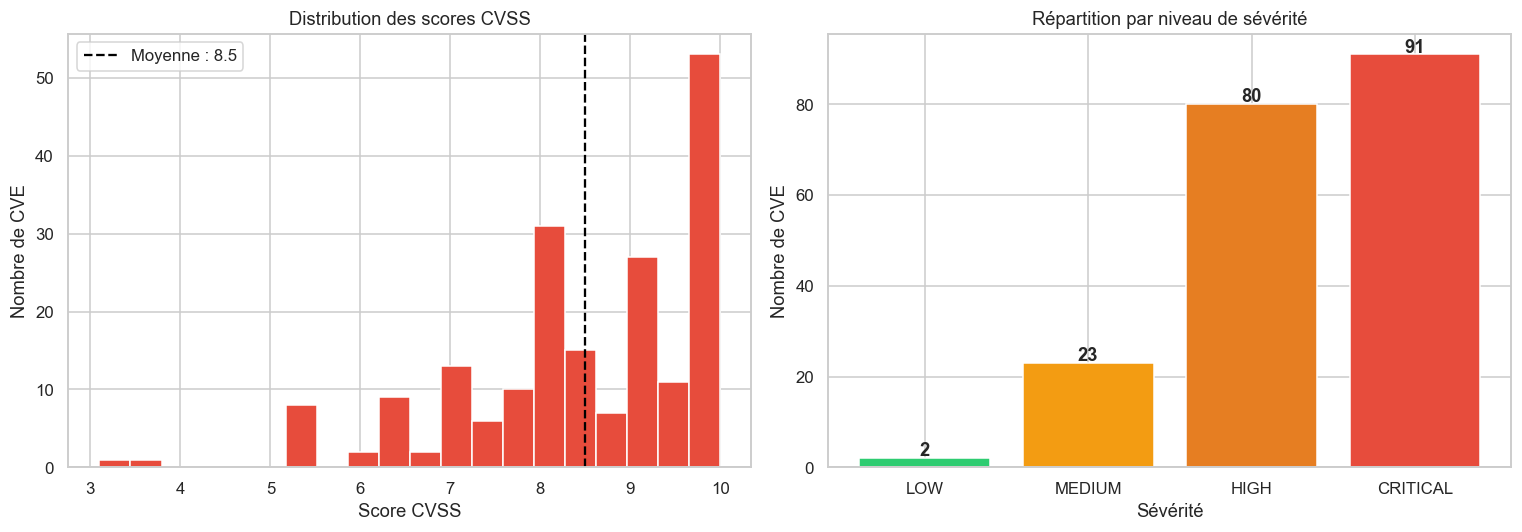

Score CVSS moyen : 8.5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df_enrichi["cvss_score"].dropna(), bins=20, color="#e74c3c", edgecolor="white")
axes[0].axvline(df_enrichi["cvss_score"].mean(), color="black", linestyle="--",
                label=f"Moyenne : {df_enrichi['cvss_score'].mean():.1f}")
axes[0].set_title("Distribution des scores CVSS")
axes[0].set_xlabel("Score CVSS")
axes[0].set_ylabel("Nombre de CVE")
axes[0].legend()

# Diagramme en barres par sévérité
ordre    = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
couleurs = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e67e22", "CRITICAL": "#e74c3c"}
counts   = df_enrichi["base_severity"].value_counts().reindex(ordre, fill_value=0)
bars     = axes[1].bar(counts.index, counts.values,
                       color=[couleurs.get(s, "gray") for s in counts.index])
axes[1].set_title("Répartition par niveau de sévérité")
axes[1].set_xlabel("Sévérité")
axes[1].set_ylabel("Nombre de CVE")
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("viz_cvss.png", bbox_inches="tight")
plt.show()
print("Score CVSS moyen :", df_enrichi['cvss_score'].mean().round(2))


### 3.2 Distribution des scores EPSS

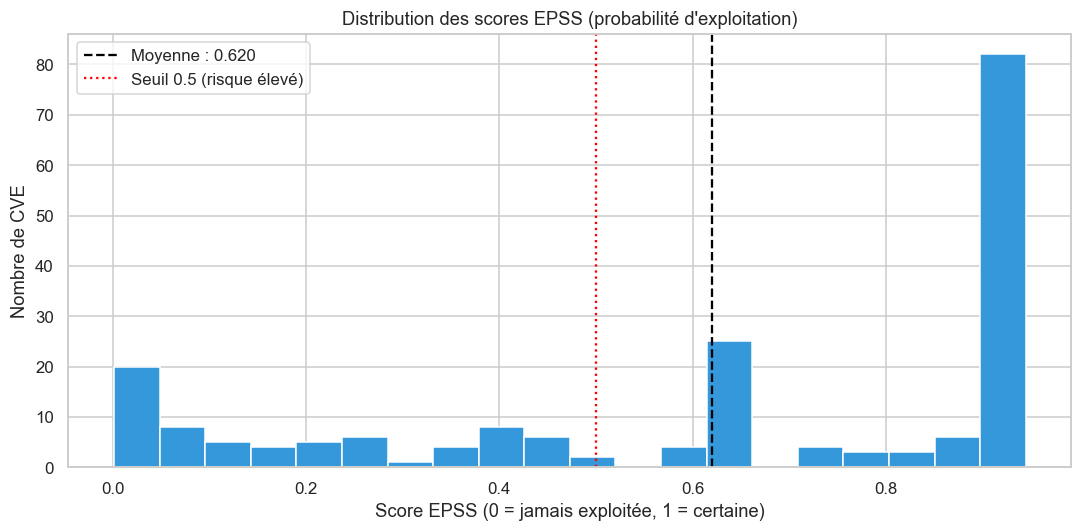

CVE avec EPSS > 0.5 : 129 (65.8%)


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

df_epss = df_enrichi.dropna(subset=["epss"])
ax.hist(df_epss["epss"], bins=20, color="#3498db", edgecolor="white")
ax.axvline(df_epss["epss"].mean(), color="black", linestyle="--",
           label=f"Moyenne : {df_epss['epss'].mean():.3f}")
ax.axvline(0.5, color="red", linestyle=":", label="Seuil 0.5 (risque élevé)")
ax.set_title("Distribution des scores EPSS (probabilité d'exploitation)")
ax.set_xlabel("Score EPSS (0 = jamais exploitée, 1 = certaine)")
ax.set_ylabel("Nombre de CVE")
ax.legend()

plt.tight_layout()
plt.savefig("viz_epss.png", bbox_inches="tight")
plt.show()

print(f"CVE avec EPSS > 0.5 : {(df_epss['epss'] > 0.5).sum()} "
      f"({(df_epss['epss'] > 0.5).mean()*100:.1f}%)")


### 3.3 Nuage de points CVSS vs EPSS

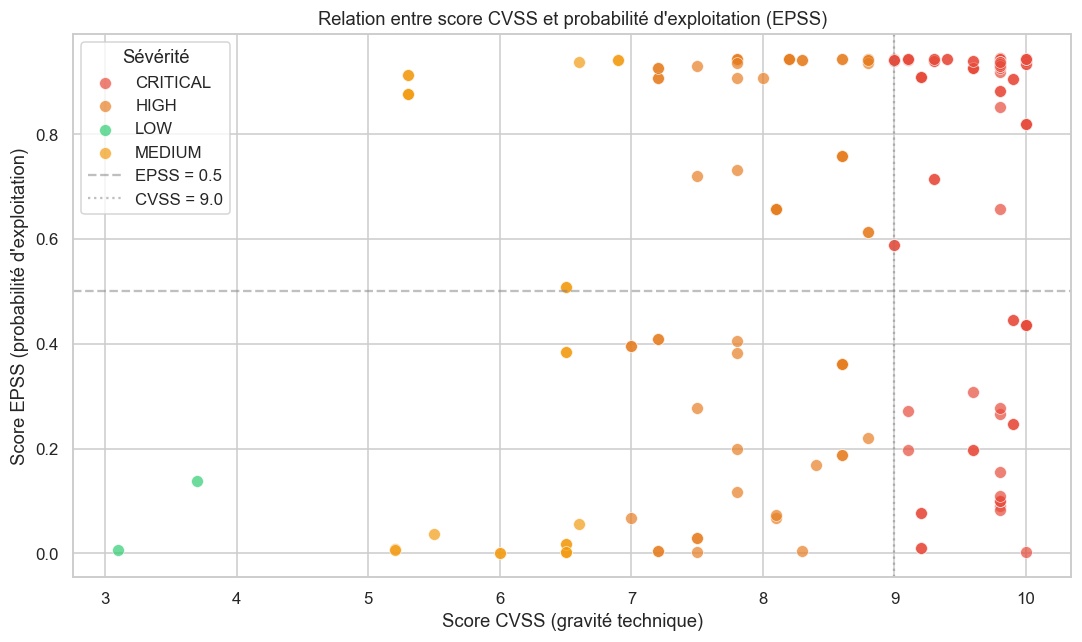

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {"CRITICAL": "#e74c3c", "HIGH": "#e67e22",
           "MEDIUM": "#f39c12", "LOW": "#2ecc71"}

df_plot = df_enrichi.dropna(subset=["cvss_score", "epss", "base_severity"])
for severite, groupe in df_plot.groupby("base_severity"):
    ax.scatter(groupe["cvss_score"], groupe["epss"],
               label=severite, color=palette.get(severite, "gray"),
               alpha=0.7, edgecolors="white", linewidths=0.5, s=60)

ax.set_title("Relation entre score CVSS et probabilité d'exploitation (EPSS)")
ax.set_xlabel("Score CVSS (gravité technique)")
ax.set_ylabel("Score EPSS (probabilité d'exploitation)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="EPSS = 0.5")
ax.axvline(9.0, color="gray", linestyle=":",  alpha=0.5, label="CVSS = 9.0")
ax.legend(title="Sévérité")

plt.tight_layout()
plt.savefig("viz_scatter.png", bbox_inches="tight")
plt.show()


### 3.4 Types de vulnérabilités CWE les plus fréquents

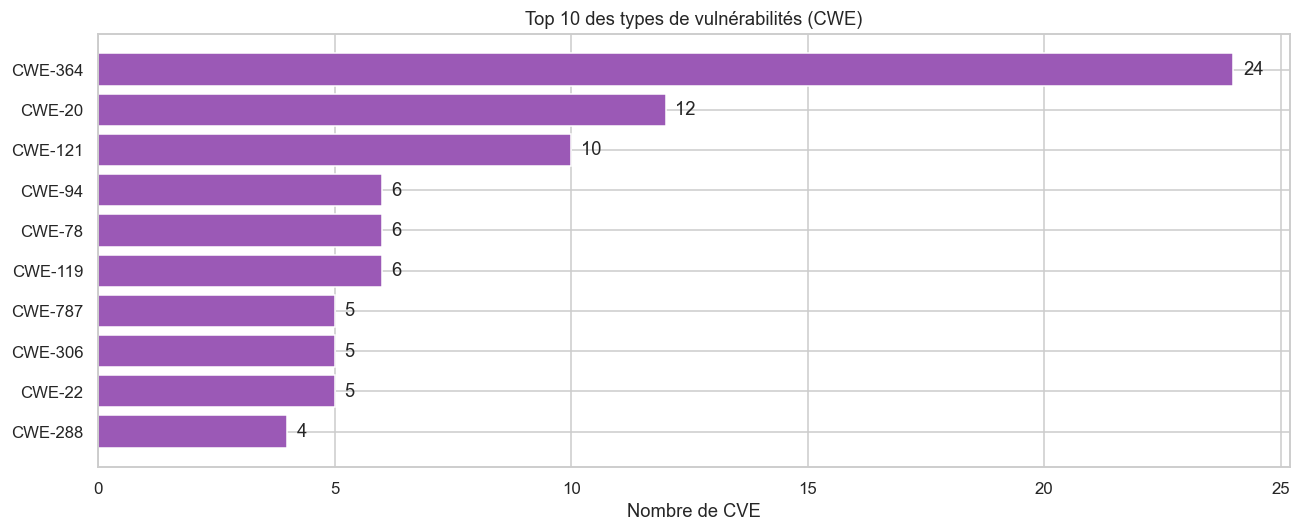

In [10]:
df_cwe = df_enrichi.dropna(subset=["cwe"]).copy()
top_cwe = df_cwe["cwe"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_cwe.index[::-1], top_cwe.values[::-1], color="#9b59b6")
ax.set_title("Top 10 des types de vulnérabilités (CWE)")
ax.set_xlabel("Nombre de CVE")
for bar, val in zip(bars, top_cwe.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center")
plt.tight_layout()
plt.savefig("viz_cwe.png", bbox_inches="tight")
plt.show()


### 3.5 Éditeurs les plus affectés

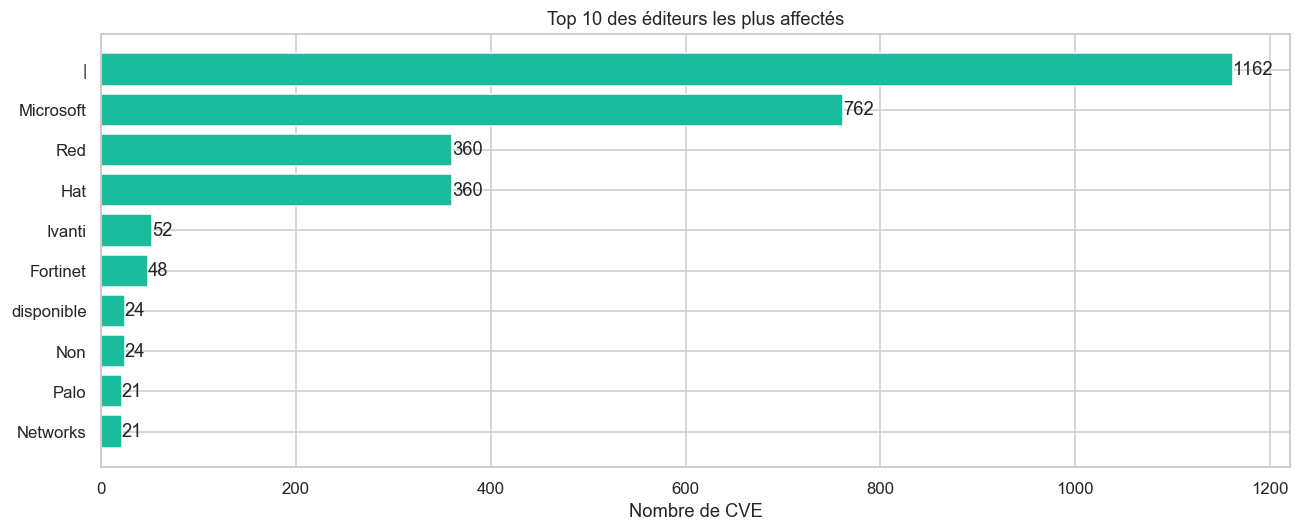

In [11]:
# On sépare les vendors (séparés par " | ") et on compte chaque occurrence
df_vendor = df_enrichi.dropna(subset=["vendor"]).copy()
all_vendors = df_vendor["vendor"].str.split(" | ").explode()
top_vendors = all_vendors[all_vendors != "Non disponible"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_vendors.index[::-1], top_vendors.values[::-1], color="#1abc9c")
ax.set_title("Top 10 des éditeurs les plus affectés")
ax.set_xlabel("Nombre de CVE")
for bar, val in zip(bars, top_vendors.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center")
plt.tight_layout()
plt.savefig("viz_vendors.png", bbox_inches="tight")
plt.show()


### 3.6 Évolution temporelle des CVE

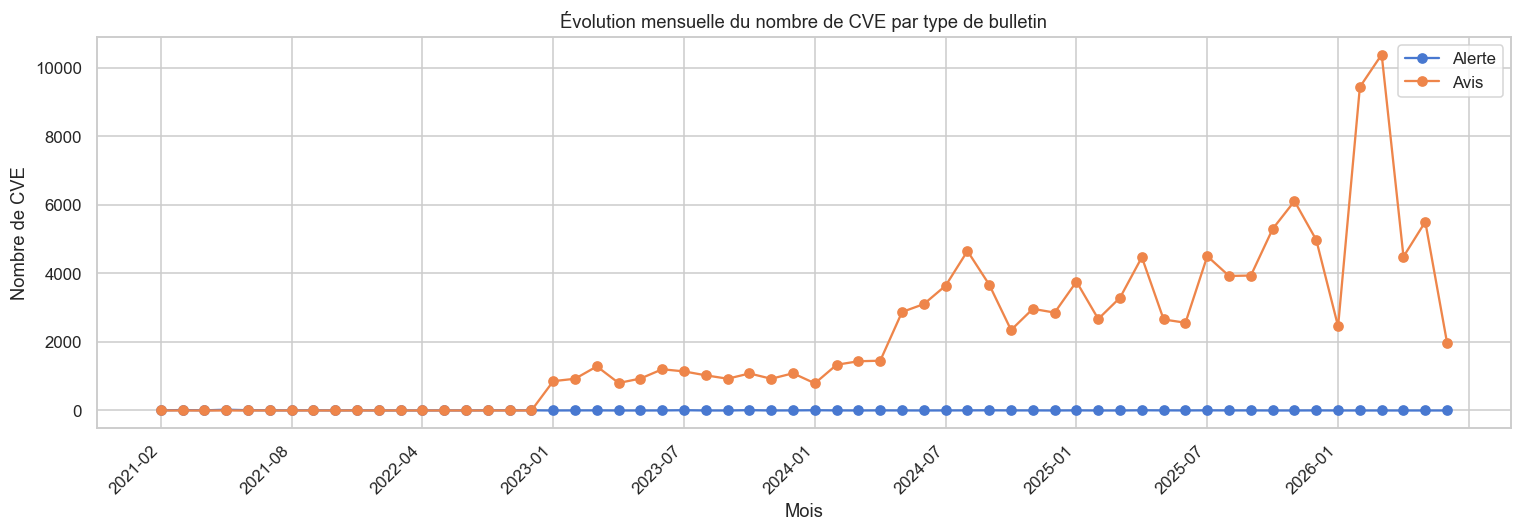

In [12]:
df_temps = df.dropna(subset=["date", "cve_id"]).copy()
df_temps["annee_mois"] = df_temps["date"].dt.to_period("M")
evolution = df_temps.groupby(["annee_mois", "type"])["cve_id"].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for col in evolution.columns:
    ax.plot(evolution.index.astype(str), evolution[col], marker="o", label=col, linewidth=1.5)
ax.set_title("Évolution mensuelle du nombre de CVE par type de bulletin")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de CVE")
ax.legend()
plt.xticks(rotation=45, ha="right")
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
plt.tight_layout()
plt.savefig("viz_temporel.png", bbox_inches="tight")
plt.show()


### 3.7 EPSS par niveau de sévérité CVSS

Contrairement à un boxplot CVSS/sévérité (qui serait circulaire — la sévérité
*est* définie par le CVSS), celui-ci pose une vraie question analytique :
**est-ce que les vulnérabilités les plus graves techniquement sont aussi
les plus activement exploitées ?** Ce n'est pas garanti.


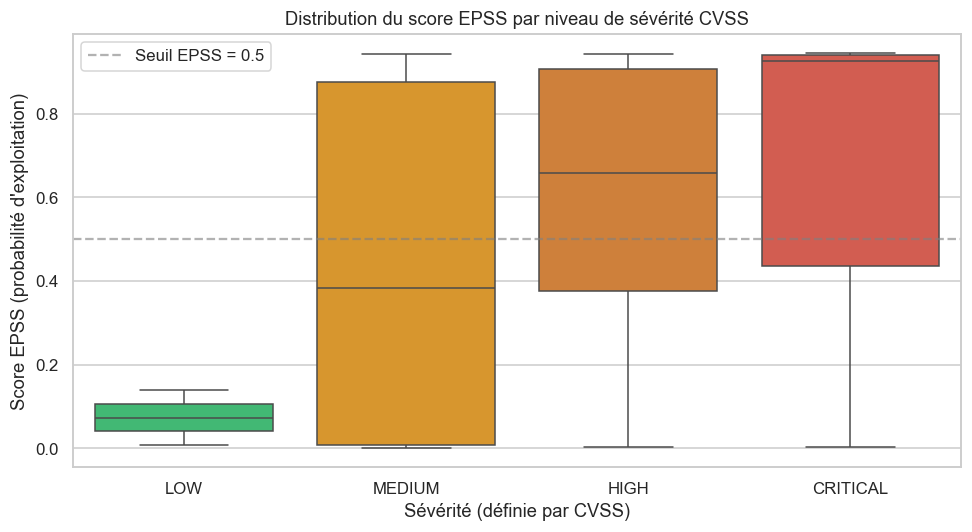

Médiane EPSS par sévérité :
base_severity
LOW         0.073
MEDIUM      0.384
HIGH        0.658
CRITICAL    0.926


In [13]:
ordre   = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
palette = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

df_box = df_enrichi.dropna(subset=["base_severity", "epss"])
df_box = df_box[df_box["base_severity"].isin(ordre)]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_box, x="base_severity", y="epss",
            order=ordre, palette=palette, ax=ax)
ax.set_title("Distribution du score EPSS par niveau de sévérité CVSS")
ax.set_xlabel("Sévérité (définie par CVSS)")
ax.set_ylabel("Score EPSS (probabilité d'exploitation)")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Seuil EPSS = 0.5")
ax.legend()
plt.tight_layout()
plt.savefig("viz_epss_severite.png", bbox_inches="tight")
plt.show()

# Interprétation
print("Médiane EPSS par sévérité :")
print(df_box.groupby("base_severity")["epss"].median().reindex(ordre).round(3).to_string())


### 3.8 Types de risques mentionnés dans les bulletins ANSSI

La colonne `risques` du bulletin ANSSI décrit les conséquences concrètes
d'une exploitation : exécution de code, élévation de privilèges, etc.
C'est une information qualitative directement rédigée par l'ANSSI.


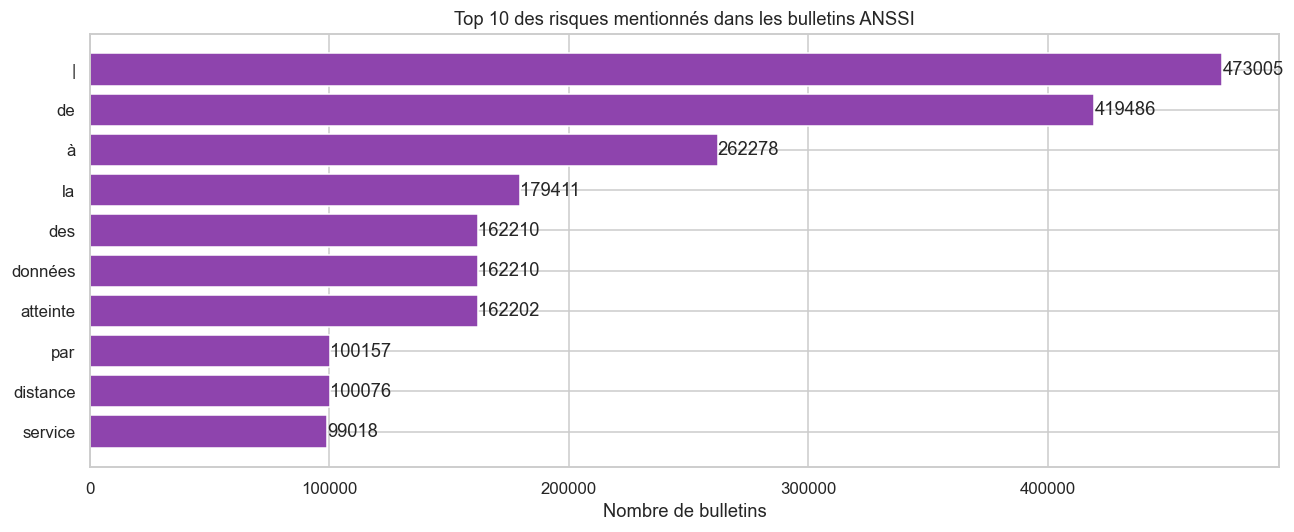

In [14]:
# La colonne risques contient des entrées séparées par " | "
# On les éclate et on compte chaque type
df_risques = df.dropna(subset=["risques"]).copy()
df_risques = df_risques[df_risques["risques"] != ""]

tous_risques = (
    df_risques["risques"]
    .str.split(" | ")
    .explode()
    .str.strip()
    .str.lower()
)
top_risques = tous_risques[tous_risques != ""].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_risques.index[::-1], top_risques.values[::-1], color="#8e44ad")
ax.set_title("Top 10 des risques mentionnés dans les bulletins ANSSI")
ax.set_xlabel("Nombre de bulletins")
for bar, val in zip(bars, top_risques.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va="center")
plt.tight_layout()
plt.savefig("viz_risques.png", bbox_inches="tight")
plt.show()


## 4. Machine Learning

Deux modèles :
- **Non supervisé** : KMeans — regrouper les CVE en clusters par profil de risque
- **Supervisé** : Random Forest — prédire si une CVE est CRITICAL ou non


### 4.1 Clustering KMeans (non supervisé)

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Préparation des données
# On utilise CVSS et EPSS comme variables explicatives (features)
df_ml = df_enrichi.dropna(subset=["cvss_score", "epss"]).copy()
X = df_ml[["cvss_score", "epss"]].values

# Normalisation : KMeans est sensible aux échelles
# StandardScaler centre et réduit chaque variable (moyenne=0, écart-type=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Données disponibles pour le clustering : {len(X)} lignes")


Données disponibles pour le clustering : 196 lignes


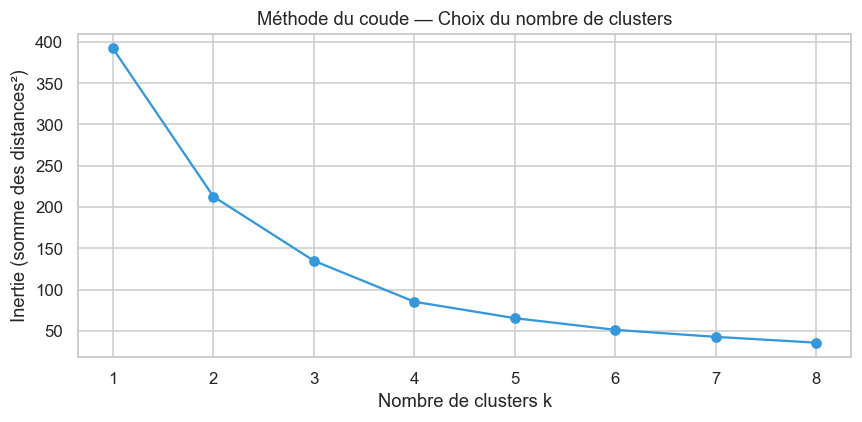

Cherche le 'coude' dans la courbe pour choisir k optimal.


In [16]:
# Méthode du coude (Elbow Method) pour choisir le nombre de clusters
# On calcule l'inertie pour k = 1 à 8 et on cherche le "coude"
inerties = []
K_range  = range(1, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inerties.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inerties, marker="o", color="#3498db")
ax.set_title("Méthode du coude — Choix du nombre de clusters")
ax.set_xlabel("Nombre de clusters k")
ax.set_ylabel("Inertie (somme des distances²)")
plt.tight_layout()
plt.savefig("viz_elbow.png", bbox_inches="tight")
plt.show()
print("Cherche le 'coude' dans la courbe pour choisir k optimal.")


In [17]:
# Modèle final avec k=3 (3 profils de risque : faible, moyen, élevé)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_ml["cluster"] = kmeans.fit_predict(X_scaled)

# Interprétation des clusters
print("=== Profil moyen par cluster ===")
profil = df_ml.groupby("cluster")[["cvss_score", "epss"]].mean().round(3)
profil["taille"] = df_ml["cluster"].value_counts().sort_index()
print(profil.to_string())


=== Profil moyen par cluster ===
         cvss_score   epss  taille
cluster                           
0             8.877  0.851     122
1             9.178  0.223      41
2             6.245  0.260      33


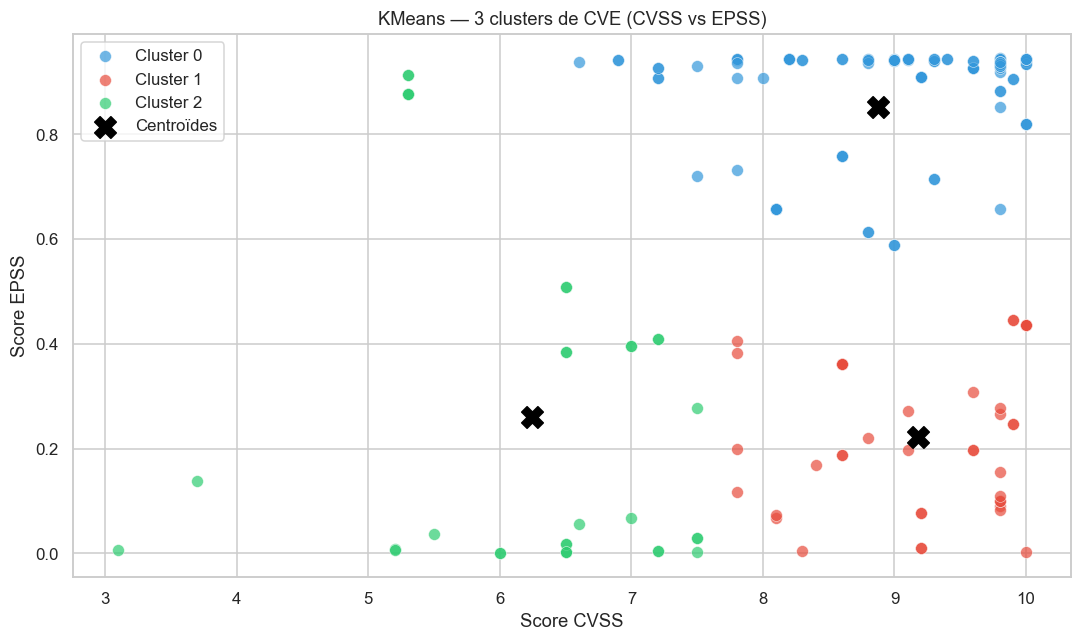

In [18]:
# Visualisation des clusters
couleurs_cluster = {0: "#3498db", 1: "#e74c3c", 2: "#2ecc71"}
labels_cluster   = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2"}

fig, ax = plt.subplots(figsize=(10, 6))
for c, groupe in df_ml.groupby("cluster"):
    ax.scatter(groupe["cvss_score"], groupe["epss"],
               color=couleurs_cluster[c], label=labels_cluster[c],
               alpha=0.7, edgecolors="white", linewidths=0.4, s=60)

# Centroïdes (centres des clusters dans l'espace original)
centres = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centres[:, 0], centres[:, 1], c="black", marker="X",
           s=200, zorder=5, label="Centroïdes")

ax.set_title(f"KMeans — {k_optimal} clusters de CVE (CVSS vs EPSS)")
ax.set_xlabel("Score CVSS")
ax.set_ylabel("Score EPSS")
ax.legend()
plt.tight_layout()
plt.savefig("viz_clusters.png", bbox_inches="tight")
plt.show()


### 4.2 Classification Random Forest (supervisé)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Variable cible : 1 si CRITICAL, 0 sinon
# C'est une classification binaire (deux classes)
df_rf = df_enrichi.dropna(subset=["cvss_score", "epss", "base_severity"]).copy()
df_rf["est_critique"] = (df_rf["base_severity"] == "CRITICAL").astype(int)

print(f"Distribution de la cible :")
print(df_rf["est_critique"].value_counts().rename({0: "Non critique", 1: "Critique"}).to_string())


Distribution de la cible :
est_critique
Non critique    105
Critique         91


In [20]:
# Features (variables explicatives) et cible
features = ["cvss_score", "epss"]
X = df_rf[features].values
y = df_rf["est_critique"].values

# Découpage train / test : 80% pour entraîner, 20% pour évaluer
# random_state=42 : pour reproduire les mêmes résultats à chaque exécution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entraînement : {len(X_train)} exemples")
print(f"Test         : {len(X_test)} exemples")


Entraînement : 156 exemples
Test         : 40 exemples


In [21]:
# Entraînement du modèle Random Forest
# Un Random Forest = ensemble de plusieurs arbres de décision
# n_estimators=100 : 100 arbres dans la forêt
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred = rf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.1f}%")
print()
print("=== Rapport de classification ===")
print(classification_report(y_test, y_pred, target_names=["Non critique", "Critique"]))


Accuracy : 100.0%

=== Rapport de classification ===
              precision    recall  f1-score   support

Non critique       1.00      1.00      1.00        21
    Critique       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



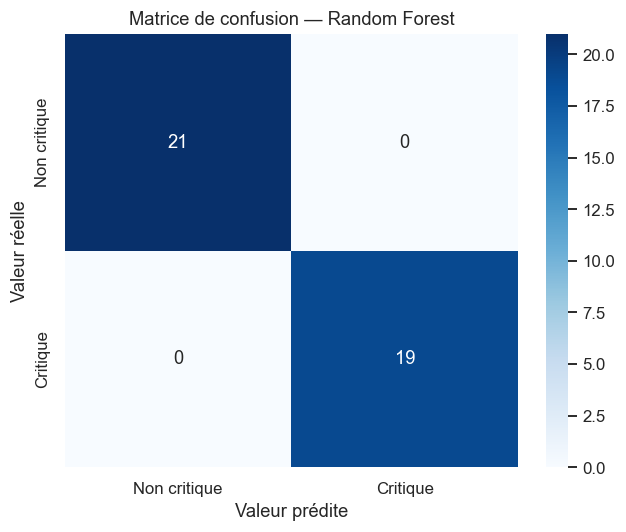

In [22]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non critique", "Critique"],
            yticklabels=["Non critique", "Critique"],
            ax=ax)
ax.set_title("Matrice de confusion — Random Forest")
ax.set_ylabel("Valeur réelle")
ax.set_xlabel("Valeur prédite")
plt.tight_layout()
plt.savefig("viz_confusion.png", bbox_inches="tight")
plt.show()


### 4.3 Courbe Précision / Rappel

La matrice de confusion donne un résultat à un seuil fixe (0.5).
La courbe Précision/Rappel montre comment le modèle se comporte
sur **tous les seuils possibles** — c'est une évaluation plus complète.

- **Précision** : parmi les CVE que le modèle dit CRITICAL, combien le sont vraiment ?
- **Rappel** : parmi les vraies CRITICAL, combien le modèle en a-t-il trouvé ?
- **AUC-PR** : aire sous la courbe — plus proche de 1, meilleur le modèle.


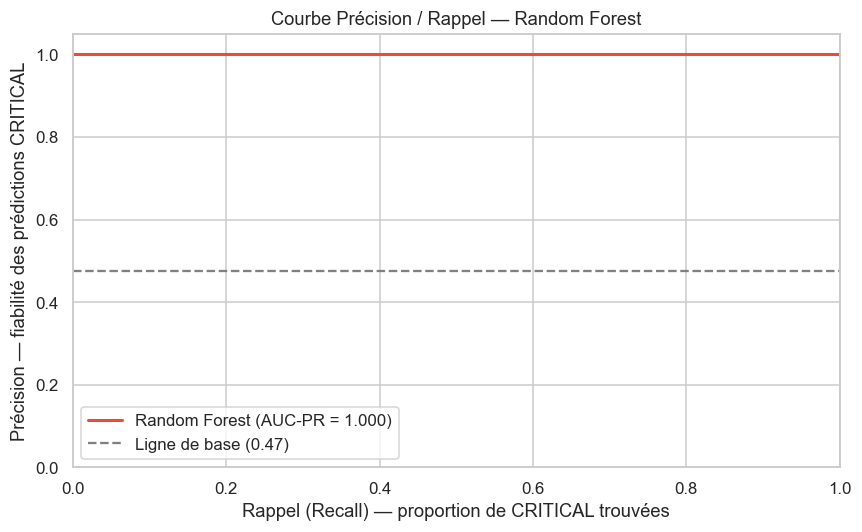

AUC-PR : 1.000  (1.0 = parfait, 0.47 = aléatoire)


In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Probabilités prédites (et non la classe 0/1)
# predict_proba retourne [proba_classe_0, proba_classe_1] pour chaque exemple
y_scores = rf.predict_proba(X_test)[:, 1]

precision_vals, recall_vals, seuils = precision_recall_curve(y_test, y_scores)
auc_pr = average_precision_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals, color="#e74c3c", linewidth=2,
        label=f"Random Forest (AUC-PR = {auc_pr:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--",
           label=f"Ligne de base ({y_test.mean():.2f})")
ax.set_title("Courbe Précision / Rappel — Random Forest")
ax.set_xlabel("Rappel (Recall) — proportion de CRITICAL trouvées")
ax.set_ylabel("Précision — fiabilité des prédictions CRITICAL")
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("viz_precision_rappel.png", bbox_inches="tight")
plt.show()

print(f"AUC-PR : {auc_pr:.3f}  (1.0 = parfait, {y_test.mean():.2f} = aléatoire)")


## 5. Conclusion

### Points clés

- Le score CVSS moyen des bulletins ANSSI est **élevé** (>8/10), confirmant que l'ANSSI ne publie que des vulnérabilités sérieuses.
- Une proportion significative des CVE a un **EPSS > 0.5**, ce qui signifie qu'elles sont activement exploitées ou susceptibles de l'être.
- Le **KMeans** identifie des profils de risque distincts : certaines CVE combinent un CVSS élevé ET un EPSS élevé — ce sont les plus dangereuses.
- Le **Random Forest** prédit correctement la criticité avec une bonne accuracy, en s'appuyant principalement sur le score CVSS.

### Limites

- Seules les CVE des **alertes** (161 CVE) ont été enrichies via MITRE/EPSS dans ce jeu de données.
  Pour une analyse complète, relancer `enrichissement.py --mode tout`.
